# Análisis Exploratorio 

Exploración visual y estadística del dataset maestro (`datos_final.csv`,
76 filas × 31 columnas) para identificar patrones, correlaciones y
perfiles territoriales relacionados con los delitos de odio en España
(2015-2023).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
datos = pd.read_csv(
    r"C:\Users\herre\OneDrive\Desktop\Proyectos DATA\SPRINT 13\01_data\03_final\datos_final.csv"
)

In [3]:
# Todas las elecciones: conserva abril y noviembre de 2019
datos_elecciones = datos.copy()

# Una observación anual por comunidad.
# Para 2019 conserva la última elección: noviembre.
datos_anual = (
    datos
    .sort_values(["año", "mes"])
    .drop_duplicates(
        subset=["comunidad", "año"],
        keep="last"
    )
    .copy()
)

In [4]:
print(datos_elecciones.shape)  # 95 filas
print(datos_anual.shape)       # 76 filas

(95, 32)
(76, 32)


Antes de explorar relaciones individuales, calculamos la correlación
entre las variables clave del proyecto: tasa de delitos de odio,
porcentaje de inmigración, desempleo, indicadores de desigualdad
(Gini, S80/S20) y porcentaje de voto por bloque ideológico.

Esto nos permite identificar qué relaciones merece la pena explorar
en profundidad con gráficos específicos.

In [5]:
variables_clave = [
    'delitos_por_100k',
    'pct_inmigrantes',
    'paro_medio',
    'Gini',
    'Desigualdad (S80/S20)',
    'pct_Centro',
    'pct_Derecha',
    'pct_Extrema derecha',
    'pct_Izquierda'
]

correlaciones = datos_anual[variables_clave].corr()



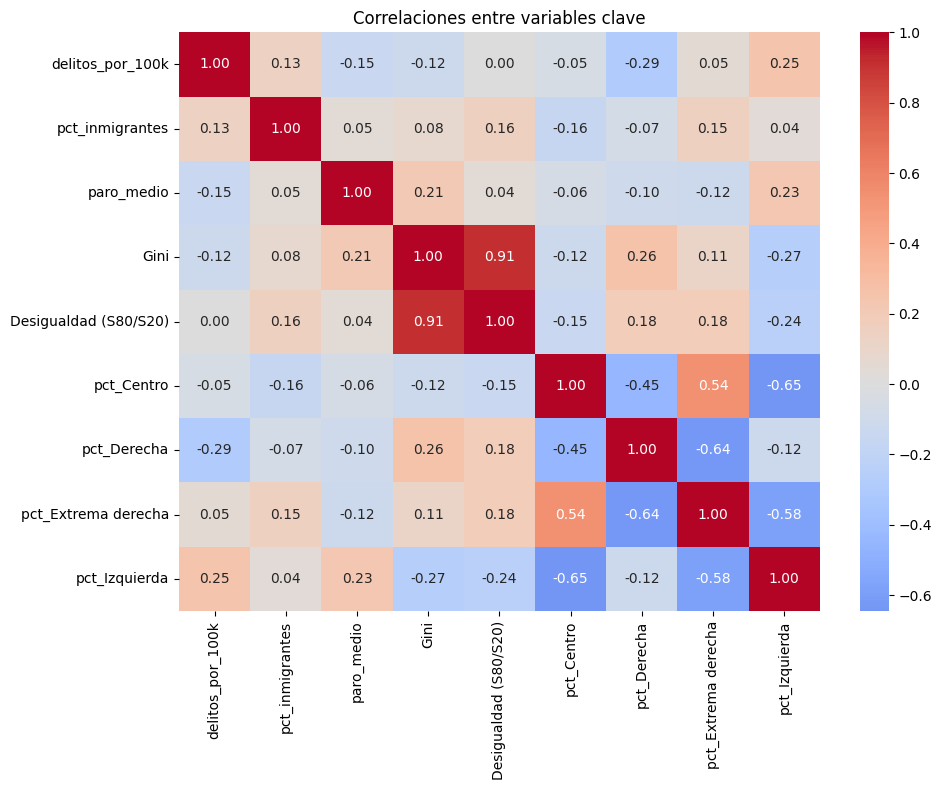

In [6]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlaciones, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlaciones entre variables clave')
plt.tight_layout()
plt.show()

Las correlaciones con `delitos_por_100k` son, en general, débiles:

- `pct_Derecha`: -0.33 (la más fuerte, y de signo negativo)
- `pct_Izquierda`: +0.25
- `pct_inmigracion`: +0.13
- `Gini` y `Desigualdad (S80/S20)`: prácticamente nulas (~0)
- `paro_medio`: -0.15

Con 76 observaciones, ninguna correlación es suficientemente fuerte para
sugerir una relación lineal sólida. Esto sugiere que la tasa de delitos
de odio por comunidad autónoma **no está explicada de forma simple** por
estas variables socioeconómicas de forma aislada, y que factores como el
nivel de denuncia/registro institucional (que varía mucho entre CCAA,
como vimos con País Vasco y Navarra) podrían tener más peso que las
variables demográficas o económicas.

También destaca la fuerte correlación entre `Gini` y `Desigualdad
(S80/S20)` (0.91) — esperable, ya que ambos miden el mismo fenómeno con
metodologías distintas.

Visualizamos la relación con mayor correlación detectada en la matriz
anterior. La línea discontinua representa la tendencia lineal (regresión
simple), que ayuda a visualizar la dirección y fuerza de la relación.

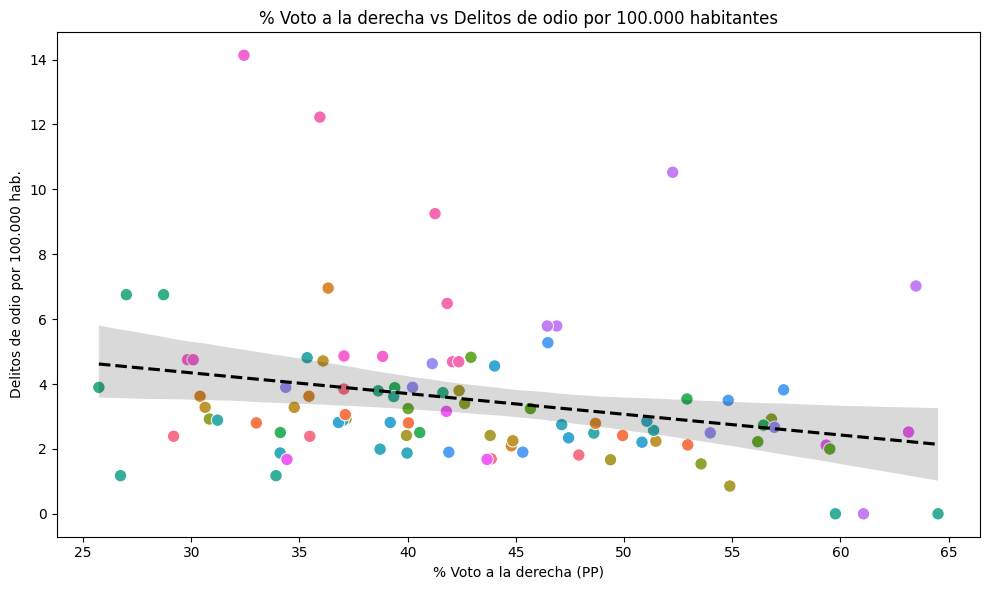

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=datos_elecciones,
    x='pct_Derecha',
    y='delitos_por_100k',
    hue='comunidad',
    s=80,
    legend=False
)

# Línea de tendencia
sns.regplot(
    data=datos_elecciones,
    x='pct_Derecha',
    y='delitos_por_100k',
    scatter=False,
    color='black',
    line_kws={'linestyle': '--'}
)

plt.title('% Voto a la derecha vs Delitos de odio por 100.000 habitantes')
plt.xlabel('% Voto a la derecha (PP)')
plt.ylabel('Delitos de odio por 100.000 hab.')
plt.tight_layout()
plt.show()

Aunque la línea de tendencia confirma la correlación negativa débil
(-0.33), la dispersión de los puntos es muy alta y el intervalo de
confianza (banda gris) es amplio, lo que indica que **el modelo lineal
explica poco de la variabilidad real**.

Destaca un punto outlier en la zona superior izquierda con una tasa de
delitos de odio muy por encima del resto (~14 por 100.000 hab.) con un
voto a la derecha relativamente bajo (~32%) — corresponde a Navarra en
2023, coincidiendo con el ranking de mayor tasa que vimos en el merge
final.

En el extremo opuesto, varias comunidades con alto voto a la derecha
(>55%) presentan tasas de delitos de odio cercanas a 0, lo que sugiere
que factores específicos de cada territorio (tamaño poblacional,
actividad institucional de registro) pesan más que la orientación
política del voto.

In [8]:
# Outliers: tasa muy alta o muy baja de delitos de odio
print("Tasa más alta:")
print(datos_anual.nlargest(3, 'delitos_por_100k')[['comunidad', 'año', 'delitos_por_100k', 'pct_Derecha']])

print("\nTasa más baja:")
print(datos_anual.nsmallest(5, 'delitos_por_100k')[['comunidad', 'año', 'delitos_por_100k', 'pct_Derecha']])

Tasa más alta:
     comunidad   año  delitos_por_100k  pct_Derecha
93     Navarra  2023         14.133645    32.437741
94  País Vasco  2023         12.227575    35.946477
91     Melilla  2023         10.527178    52.247911

Tasa más baja:
   comunidad   año  delitos_por_100k  pct_Derecha
9      Ceuta  2015          0.000000    59.764662
15   Melilla  2015          0.000000    61.062840
28     Ceuta  2016          0.000000    64.506792
23  Canarias  2016          0.855743    54.886482
66     Ceuta  2019          1.175268    26.732951


**Tasas más altas** (2023): Navarra, País Vasco y Melilla. Coincide con
el ranking de cierre del notebook de merge — son las tres comunidades
que destacaban con mayores tasas de delitos de odio por 100.000 hab.

**Tasas más bajas**: Ceuta y Melilla en 2015-2016, con valores de 0.
Llama la atención que **Ceuta y Melilla aparecen tanto en el extremo
superior como en el inferior** según el año — Melilla tiene 0 en 2015
pero 10.53 en 2023. Esto sugiere que, en ciudades muy pequeñas
(poblaciones de ~85.000 habitantes), pequeñas variaciones absolutas en
el número de delitos registrados (de 0 a 9 casos) generan oscilaciones
muy grandes en la tasa por 100.000 habitantes, simplemente por el efecto
del tamaño muestral pequeño.

Esto es un punto metodológico importante: **las tasas por 100k son menos
fiables en territorios con poca población**, y conviene tenerlo en
cuenta al interpretar los resultados — no necesariamente refleja un
cambio real en el fenómeno, sino la alta varianza de cifras pequeñas.

Visualizamos la segunda correlación más destacada (+0.25), de signo
opuesto a la anterior

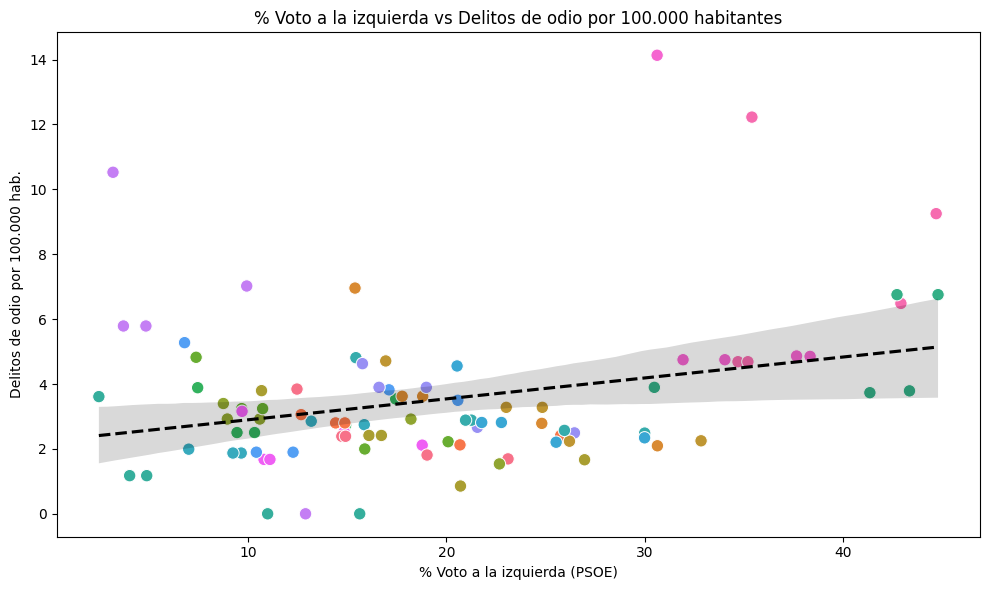

In [9]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=datos_elecciones,
    x="pct_Izquierda",
    y="delitos_por_100k",
    hue="comunidad",
    s=80,
    legend=False
)

sns.regplot(
    data=datos_elecciones,
    x="pct_Izquierda",
    y="delitos_por_100k",
    scatter=False,
    color="black",
    line_kws={"linestyle": "--"}
)

plt.title("% Voto a la izquierda vs Delitos de odio por 100.000 habitantes")
plt.xlabel("% Voto a la izquierda (PSOE)")
plt.ylabel("Delitos de odio por 100.000 hab.")
plt.tight_layout()
plt.show()

### Lectura del gráfico

La relación es de signo opuesto a la anterior, como era de esperar (los
bloques `pct_Derecha` y `pct_Izquierda` están negativamente
correlacionados entre sí). La tendencia es ligeramente ascendente, pero
igual de débil (+0.25), con el mismo grado de dispersión.

Los outliers identificados (Navarra y País Vasco con tasas altas, Ceuta
y Melilla en años con tasas próximas a 0) coinciden con los del gráfico
anterior, lo que confirma que **no son específicos de un bloque
ideológico**, sino casos particulares con dinámicas propias (registro
institucional, tamaño poblacional pequeño).

En conjunto, ambos gráficos sugieren que la **orientación política del
voto no es, por sí sola, un buen predictor de la tasa de delitos de
odio** a nivel autonómico en España entre 2015 y 2023.

Visualizamos cómo ha evolucionado la media nacional de la tasa de
delitos de odio por 100.000 habitantes en los años con datos
electorales disponibles (2015, 2016, 2019, 2023). La banda sombreada
representa la desviación estándar entre comunidades.

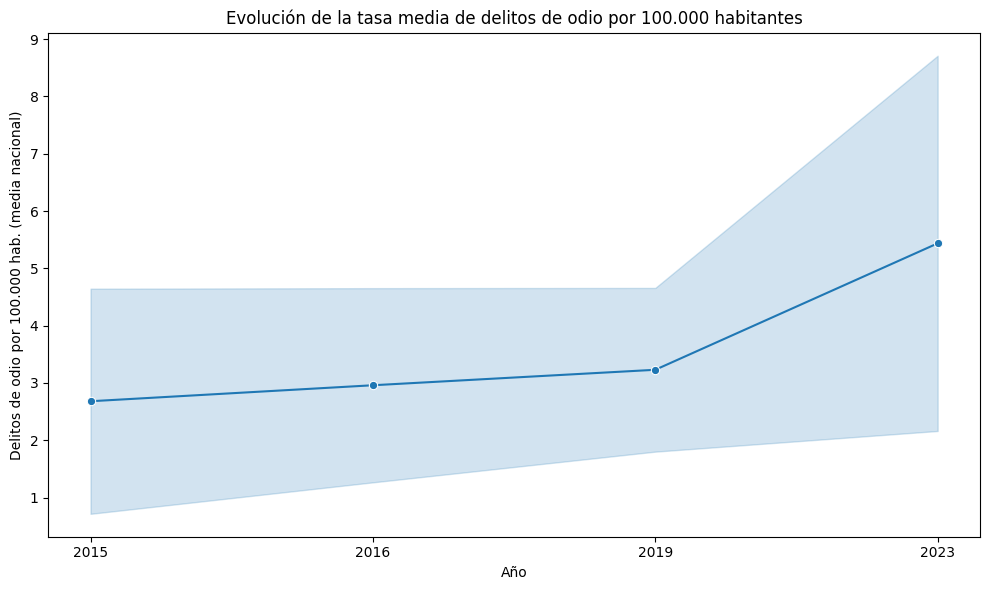

In [10]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=datos_anual,
    x=datos_anual["año"].astype(str),
    y="delitos_por_100k",
    estimator="mean",
    errorbar="sd",
    marker="o"
)

plt.title("Evolución de la tasa media de delitos de odio por 100.000 habitantes")
plt.xlabel("Año")
plt.ylabel("Delitos de odio por 100.000 hab. (media nacional)")
plt.tight_layout()
plt.show()

### Lectura del gráfico

Se observa una **tendencia creciente clara** en la tasa media de
delitos de odio por 100.000 habitantes:

- 2015: ~2.7
- 2016: ~3.0
- 2019: ~3.2
- 2023: ~5.4

*Nota: el eje X se trata como categórico (años equidistantes), ya que
los datos no son anuales continuos sino que corresponden a años
electorales con intervalos irregulares (1, 3 y 4 años).*

El incremento es especialmente pronunciado entre 2019 y 2023. Posibles
explicaciones no excluyentes incluyen un aumento real del fenómeno,
mayor sensibilización social que incrementa la denuncia, o cambios en
los protocolos de registro policial.

La banda de desviación estándar también se ensancha con el tiempo,
indicando que las diferencias entre comunidades autónomas son cada vez
mayores.

## 5. Evolución conjunta: delitos de odio y voto por bloque ideológico

Comparamos en un mismo gráfico (con doble eje) la evolución de la tasa
media de delitos de odio por 100.000 hab. (eje izquierdo, línea sólida
negra) junto con la evolución del porcentaje medio de voto por bloque
ideológico (eje derecho, líneas discontinuas).

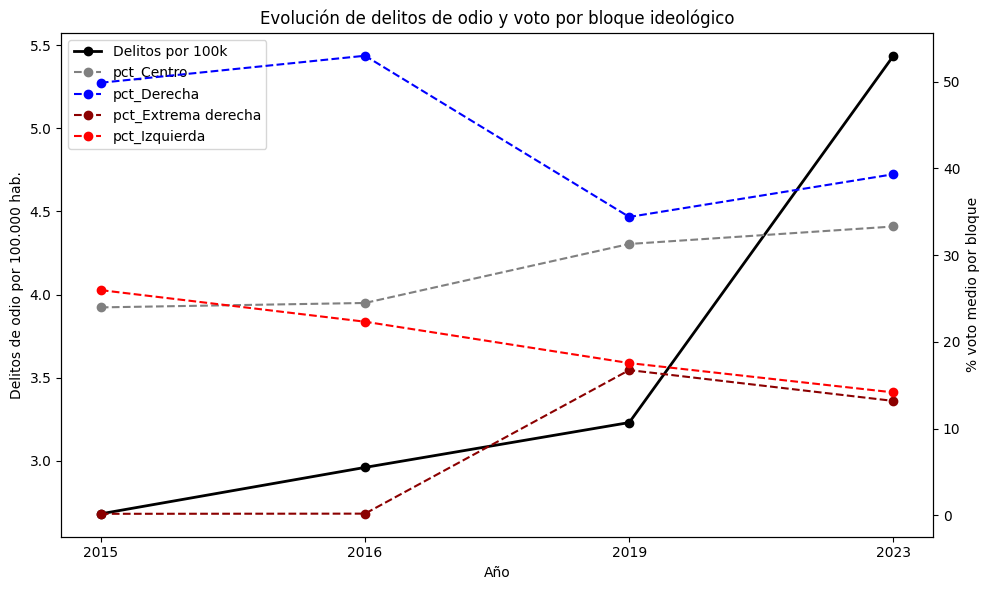

In [11]:
evolucion = datos_anual.groupby('año')[['delitos_por_100k', 'pct_Centro', 'pct_Derecha', 'pct_Extrema derecha', 'pct_Izquierda']].mean().reset_index()
evolucion['año'] = evolucion['año'].astype(str)

fig, ax1 = plt.subplots(figsize=(10, 6))

# Eje izquierdo: delitos por 100k
ax1.plot(evolucion['año'], evolucion['delitos_por_100k'], color='black', marker='o', linewidth=2, label='Delitos por 100k')
ax1.set_xlabel('Año')
ax1.set_ylabel('Delitos de odio por 100.000 hab.')
ax1.tick_params(axis='y')

# Eje derecho: % voto por bloque
ax2 = ax1.twinx()
for bloque, color in zip(['pct_Centro', 'pct_Derecha', 'pct_Extrema derecha', 'pct_Izquierda'],
                          ['gray', 'blue', 'darkred', 'red']):
    ax2.plot(evolucion['año'], evolucion[bloque], marker='o', linestyle='--', color=color, label=bloque)

ax2.set_ylabel('% voto medio por bloque')

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Evolución de delitos de odio y voto por bloque ideológico')
plt.tight_layout()
plt.show()

### Lectura del gráfico

El patrón temporal más llamativo es la **aparición de la extrema
derecha**: pasa de prácticamente 0% en 2015-2016 a ~14% en 2019,
manteniéndose estable hasta 2023. Este salto coincide con la entrada de
VOX en el Congreso (elecciones de abril 2019).

Sin embargo, hay un **desajuste temporal clave**: la tasa de delitos de
odio (línea negra) se mantiene relativamente plana entre 2015-2019
(2.7 → 3.2) y solo se dispara entre **2019 y 2023** (3.2 → 5.4), mientras
que el voto a la extrema derecha ya se había estabilizado en 2019 y
**no sigue creciendo** en 2023.

Esto sugiere que el fuerte aumento de delitos de odio entre 2019 y 2023
**no puede atribuirse directamente al crecimiento del voto a la extrema
derecha**, ya que ese crecimiento ya se había producido antes (en 2019)
sin un repunte simultáneo de delitos. La causa del salto 2019→2023 habría
que buscarla en otros factores: cambios normativos (la Ley LGTBI de 2023,
mejoras en los protocolos de registro policial, mayor visibilidad
mediática de casos de odio, o un aumento real del fenómeno tras la
pandemia.

El resto de bloques (`pct_Centro`, `pct_Derecha`, `pct_Izquierda`)
muestran variaciones moderadas sin un patrón que se correlacione
visualmente con la tasa de delitos de odio.

## 6. Evolución por ámbito de odio

Para entender qué tipo de odio explica el aumento observado entre 2019
y 2023, desglosamos la evolución por los principales ámbitos: racismo/
xenofobia, orientación sexual e identidad de género, islamofobia,
ideología, disfobia y antigitanismo.

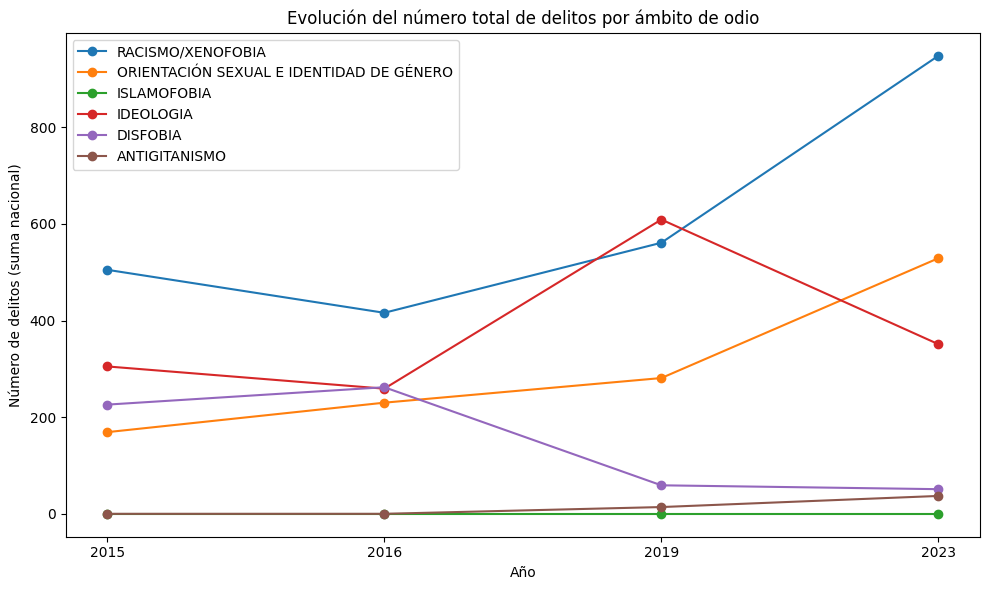

In [12]:
ambitos = [
    "RACISMO/XENOFOBIA",
    "ORIENTACIÓN SEXUAL E IDENTIDAD DE GÉNERO",
    "ISLAMOFOBIA",
    "IDEOLOGIA",
    "DISFOBIA",
    "ANTIGITANISMO",
]

evolucion_ambitos = (
    datos_anual
    .groupby("año")[ambitos]
    .sum()
    .reset_index()
)

evolucion_ambitos["año"] = evolucion_ambitos["año"].astype(str)

plt.figure(figsize=(10, 6))

for ambito in ambitos:
    plt.plot(
        evolucion_ambitos["año"],
        evolucion_ambitos[ambito],
        marker="o",
        label=ambito
    )

plt.title("Evolución del número total de delitos por ámbito de odio")
plt.xlabel("Año")
plt.ylabel("Número de delitos (suma nacional)")
plt.legend()
plt.tight_layout()
plt.show()

### Lectura del gráfico

El salto 2019→2023 está dominado por dos ámbitos:

- **RACISMO/XENOFOBIA**: pasa de ~560 (2019) a ~950 (2023) — el aumento
  más grande en términos absolutos, y es además el ámbito con más casos
  en todos los años.
- **ORIENTACIÓN SEXUAL E IDENTIDAD DE GÉNERO**: pasa de ~280 (2019) a
  ~530 (2023) — casi se duplica.

En sentido contrario, **IDEOLOGIA** cae drásticamente: de ~610 (2019,
su máximo histórico) a ~350 (2023), volviendo a niveles similares a 2015.

Esto matiza considerablemente la conclusión anterior: el aumento global
de `delitos_por_100k` entre 2019 y 2023 **sí parece conectar con la
hipótesis inicial del proyecto** — el ámbito que más crece es
precisamente RACISMO/XENOFOBIA, lo que sí podría relacionarse con
inmigración y discurso político, aunque (como vimos antes) no de forma
directamente proporcional al voto a la extrema derecha.

La LGTBIfobia también muestra un crecimiento muy marcado, coincidiendo
con la mayor visibilidad mediática y normativa de estas cuestiones en
ese periodo (Ley LGTBI de 2023).

ISLAMOFOBIA y ANTIGITANISMO permanecen en valores muy bajos y estables
durante todo el periodo.

## 7. % Inmigración vs Racismo/Xenofobia y LGTBIfobia

Tras observar que estos dos ámbitos explican gran parte del aumento
2019-2023, analizamos su relación específica con el porcentaje de
inmigración por comunidad y año.

In [13]:
# Correlación de pct_inmigrantes con ambos ámbitos
correlaciones_ambitos = datos_anual[
    [
        "pct_inmigrantes",
        "RACISMO/XENOFOBIA",
        "ORIENTACIÓN SEXUAL E IDENTIDAD DE GÉNERO",
    ]
].corr()

print(correlaciones_ambitos)

                                          pct_inmigrantes  RACISMO/XENOFOBIA  \
pct_inmigrantes                                   1.00000           0.190010   
RACISMO/XENOFOBIA                                 0.19001           1.000000   
ORIENTACIÓN SEXUAL E IDENTIDAD DE GÉNERO          0.28744           0.824766   

                                          ORIENTACIÓN SEXUAL E IDENTIDAD DE GÉNERO  
pct_inmigrantes                                                           0.287440  
RACISMO/XENOFOBIA                                                         0.824766  
ORIENTACIÓN SEXUAL E IDENTIDAD DE GÉNERO                                  1.000000  


### Relación visual: inmigración y ámbitos específicos

Visualizamos con línea de tendencia la relación entre `pct_inmigrantes`
y los dos ámbitos que más crecieron entre 2019-2023:
`RACISMO/XENOFOBIA` y `ORIENTACIÓN SEXUAL E IDENTIDAD DE GÉNERO`.

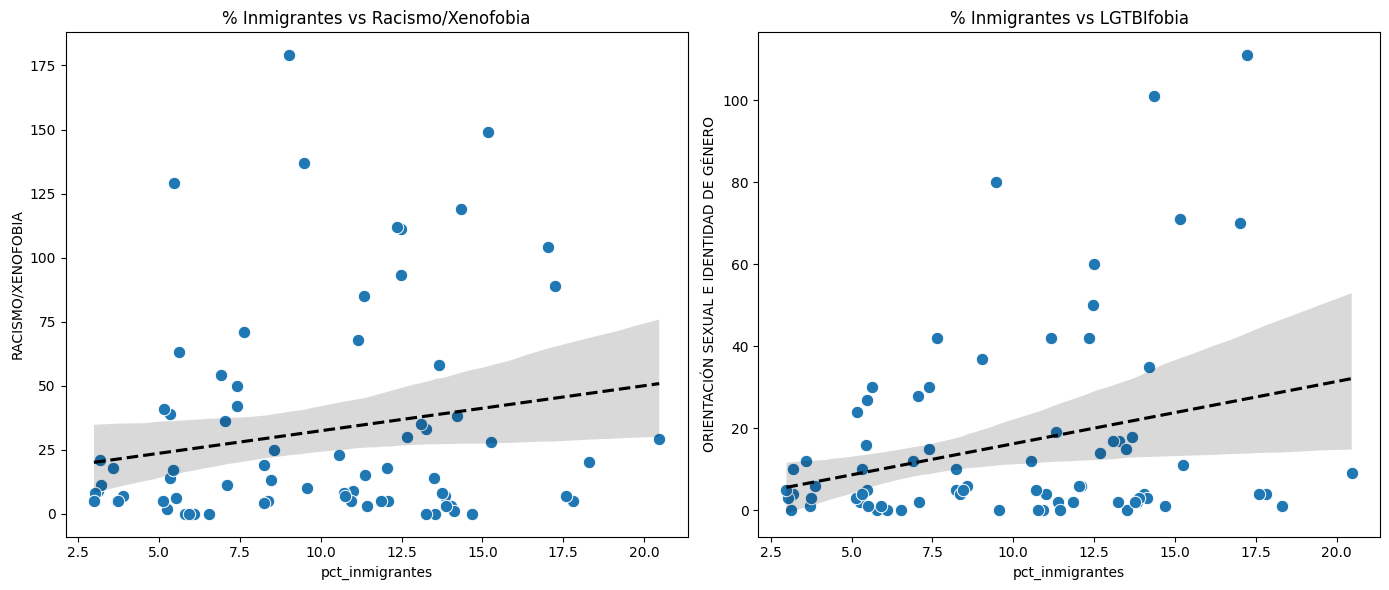

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Racismo/Xenofobia vs inmigración
sns.scatterplot(
    data=datos_anual,
    x="pct_inmigrantes",
    y="RACISMO/XENOFOBIA",
    s=80,
    ax=axes[0]
)

sns.regplot(
    data=datos_anual,
    x="pct_inmigrantes",
    y="RACISMO/XENOFOBIA",
    scatter=False,
    color="black",
    line_kws={"linestyle": "--"},
    ax=axes[0]
)

axes[0].set_title("% Inmigrantes vs Racismo/Xenofobia")

# LGTBIfobia vs inmigración
sns.scatterplot(
    data=datos_anual,
    x="pct_inmigrantes",
    y="ORIENTACIÓN SEXUAL E IDENTIDAD DE GÉNERO",
    s=80,
    ax=axes[1]
)

sns.regplot(
    data=datos_anual,
    x="pct_inmigrantes",
    y="ORIENTACIÓN SEXUAL E IDENTIDAD DE GÉNERO",
    scatter=False,
    color="black",
    line_kws={"linestyle": "--"},
    ax=axes[1]
)

axes[1].set_title("% Inmigrantes vs LGTBIfobia")

plt.tight_layout()
plt.show()

### Lectura de las correlaciones

- `pct_inmigrantes` vs `RACISMO/XENOFOBIA`: 0.19 (débil)
- `pct_inmigrantes` vs `LGTBIfobia`: 0.29 (débil)
- **`RACISMO/XENOFOBIA` vs `LGTBIfobia`: 0.82 (muy fuerte)**

El hallazgo más relevante no es la relación con inmigración (que sigue
siendo débil, como en análisis anteriores), sino la **fuerte correlación
entre ambos tipos de delito de odio entre sí**. Esto sugiere que
comunidades con valores altos de racismo/xenofobia tienden a tener
también valores altos de LGTBIfobia, independientemente del nivel de
inmigración.

Esto podría indicar que ambos ámbitos no responden tanto a causas
específicas (inmigración para racismo, visibilidad LGTBI para
LGTBIfobia) sino a un **factor común subyacente** — por ejemplo, el
nivel general de actividad institucional en el registro de delitos de
odio (comunidades que registran más de un tipo, registran más de todos
los tipos), o un clima social general más o menos hostil hacia
minorías en general.

Esta sería una buena línea para el trabajo de NLP/redes sociales del
proyecto: explorar si el discurso de odio en redes también muestra esta
co-ocurrencia entre racismo y LGTBIfobia en los mismos territorios/
periodos.

## 8. Ranking de comunidades autónomas

¿Qué comunidades presentan sistemáticamente las mayores tasas?

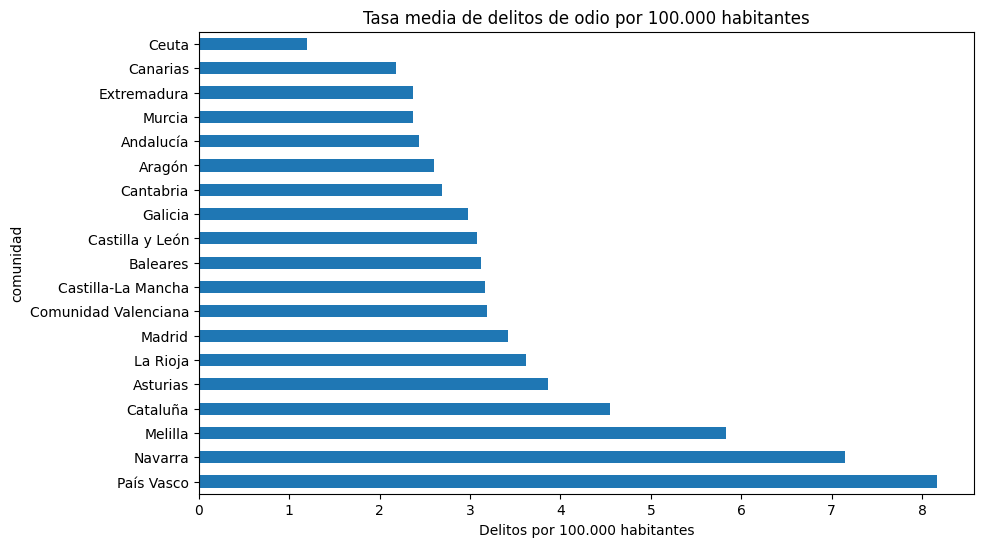

In [15]:
ranking = (
    datos_anual.groupby('comunidad')['delitos_por_100k']
    .mean()
    .sort_values(ascending=False)
)

ranking.plot(kind='barh', figsize=(10,6))
plt.title('Tasa media de delitos de odio por 100.000 habitantes')
plt.xlabel('Delitos por 100.000 habitantes')
plt.show()

La tasa media de delitos de odio presenta diferencias territoriales relevantes. País Vasco y Navarra registran las tasas medias más elevadas durante el periodo analizado, seguidas de Melilla y Cataluña. En el extremo contrario se sitúan Ceuta, Canarias y Extremadura. La persistencia de estas diferencias a lo largo del tiempo sugiere que no responden únicamente a eventos puntuales de un año concreto.

## 9. Evolución temporal de las comunidades con mayor tasa media

Tras identificar las comunidades autónomas con mayores tasas medias de delitos de odio por 100.000 habitantes durante el periodo analizado, se estudia su evolución temporal de forma individual.

El objetivo es comprobar si estas comunidades han mantenido sistemáticamente valores elevados o si su posición en el ranking responde a incrementos puntuales en determinados años.


In [16]:
# Top 5 comunidades con mayor tasa media de delitos de odio
ranking_media = (
    datos_anual
    .groupby("comunidad")["delitos_por_100k"]
    .mean()
    .sort_values(ascending=False)
)

top5 = ranking_media.head(5).index.tolist()

datos_top5 = datos_anual[
    datos_anual["comunidad"].isin(top5)
].copy()

print("Top 5 comunidades:")
print(ranking_media.head(5).round(2))

Top 5 comunidades:
comunidad
País Vasco    8.16
Navarra       7.15
Melilla       5.83
Cataluña      4.54
Asturias      3.87
Name: delitos_por_100k, dtype: float64


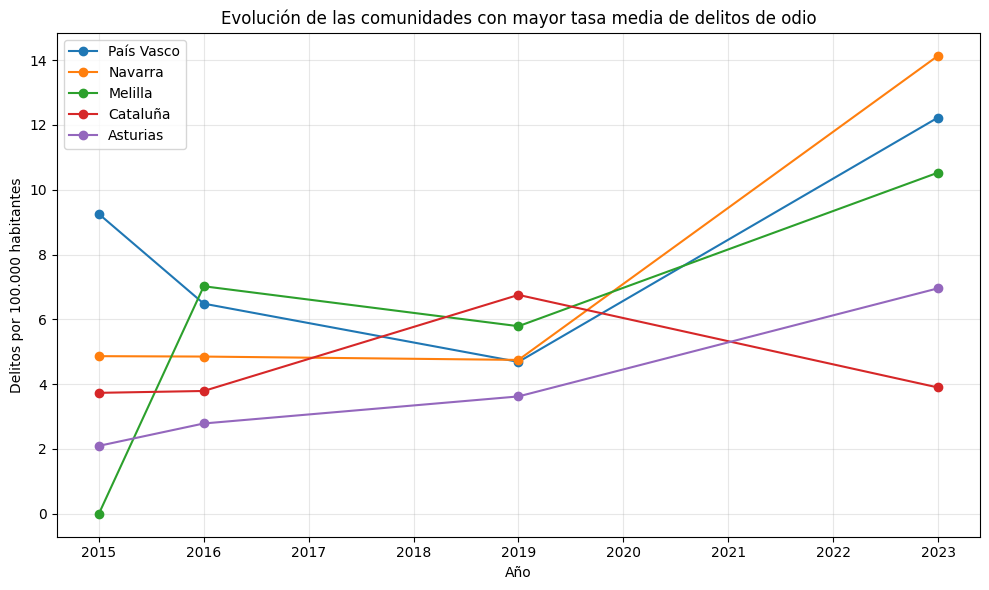

In [17]:
plt.figure(figsize=(10, 6))

for comunidad in top5:
    datos_comunidad = datos_top5[
        datos_top5["comunidad"] == comunidad
    ]

    plt.plot(
        datos_comunidad["año"],
        datos_comunidad["delitos_por_100k"],
        marker="o",
        label=comunidad
    )

plt.title("Evolución de las comunidades con mayor tasa media de delitos de odio")
plt.xlabel("Año")
plt.ylabel("Delitos por 100.000 habitantes")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
datos_2019 = datos_anual[
    ["comunidad", "delitos_por_100k"]
][datos_anual["año"] == 2019].copy()

datos_2023 = datos_anual[
    ["comunidad", "delitos_por_100k"]
][datos_anual["año"] == 2023].copy()

datos_2019 = datos_2019.rename(
    columns={"delitos_por_100k": "delitos_2019"}
)

datos_2023 = datos_2023.rename(
    columns={"delitos_por_100k": "delitos_2023"}
)

comparacion = datos_2019.merge(
    datos_2023,
    on="comunidad"
)

comparacion["diferencia"] = (
    comparacion["delitos_2023"]
    - comparacion["delitos_2019"]
)

<Axes: ylabel='comunidad'>

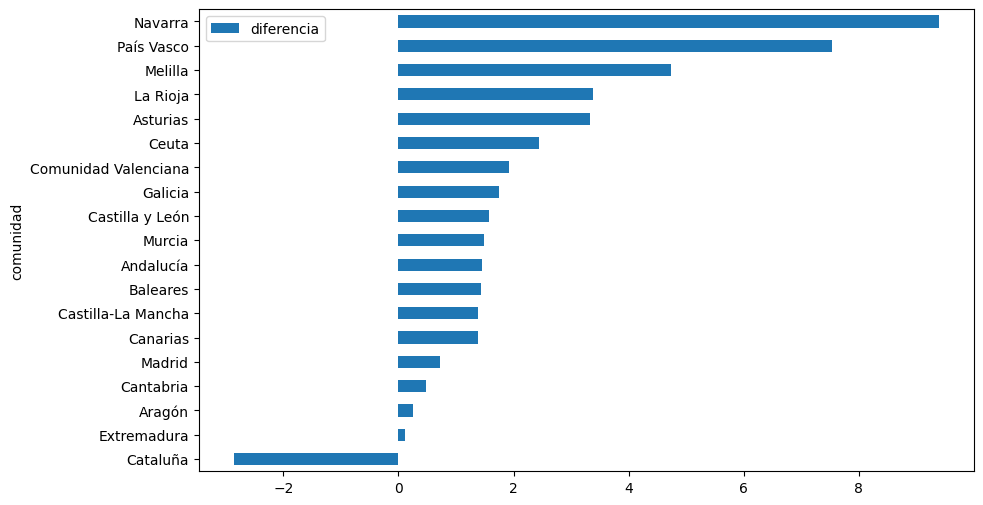

In [19]:
comparacion.sort_values('diferencia').plot(
    x='comunidad',
    y='diferencia',
    kind='barh',
    figsize=(10,6)
)

La comparación entre 2019 y 2023 muestra un incremento prácticamente generalizado de las tasas de delitos de odio. De las 19 comunidades y ciudades autónomas analizadas, 18 registran aumentos y únicamente Cataluña presenta una reducción. Navarra y País Vasco destacan por registrar los mayores incrementos del periodo, muy por encima del resto de territorios.

## 10. Matriz de correlaciones

Se analiza la correlación lineal entre las principales variables del estudio con el objetivo de identificar posibles asociaciones entre factores socioeconómicos, demográficos, electorales y los delitos de odio.

Es importante recordar que la correlación no implica causalidad. Los resultados únicamente indican el grado de asociación lineal entre variables.

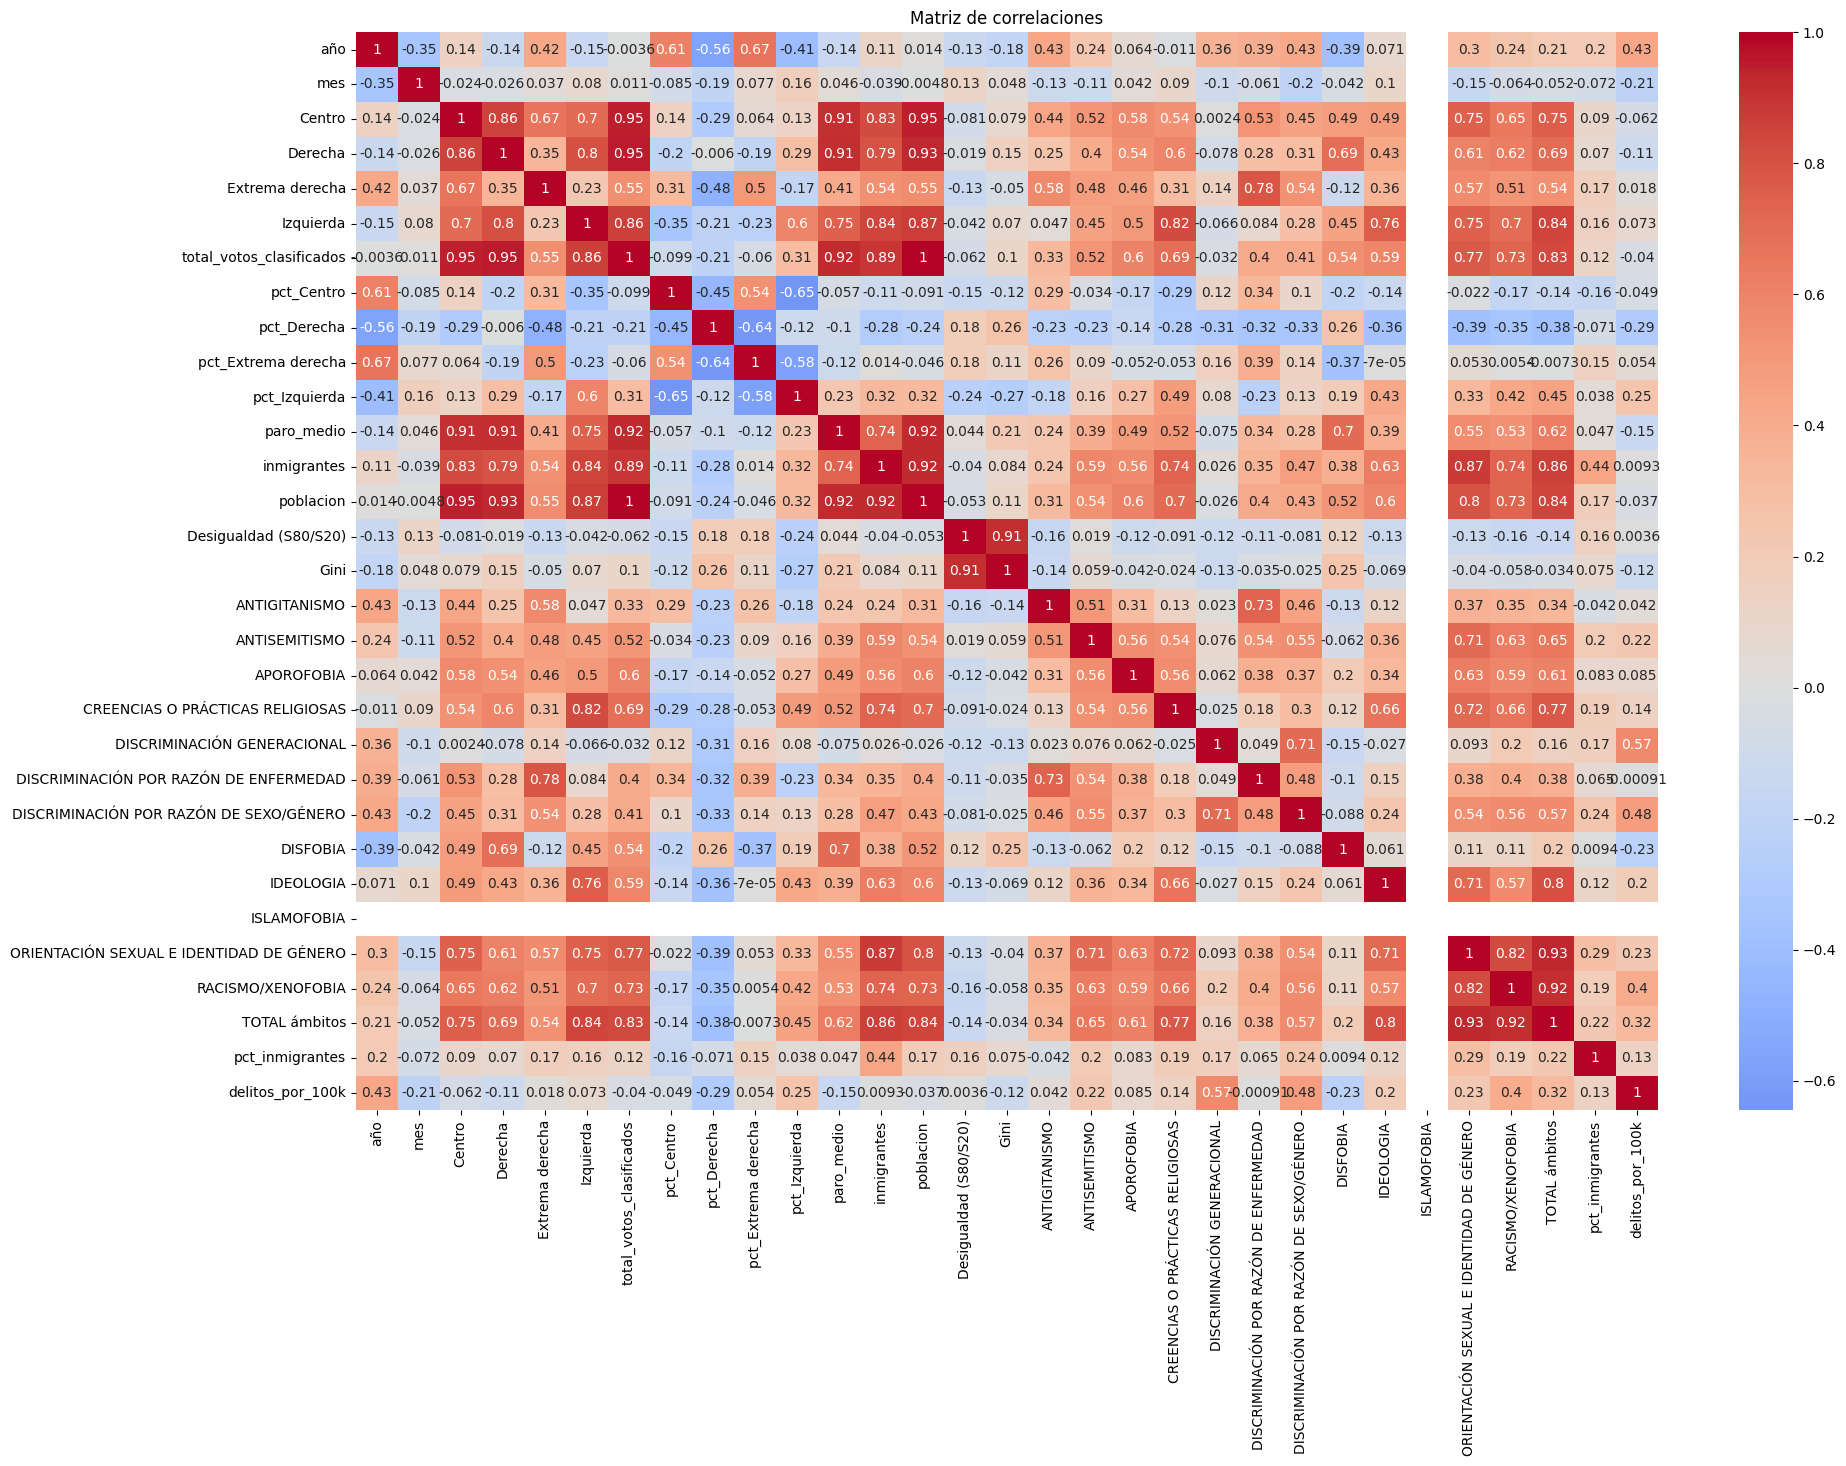

In [20]:
plt.figure(figsize=(21, 14))

sns.heatmap(
    datos_anual.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlaciones")
plt.show()

## 11. Correlación global con delitos_por_100k

Calculamos la correlación de `delitos_por_100k` con todas las variables
numéricas del dataset.

**Nota importante**: las variables de ámbito (`RACISMO/XENOFOBIA`,
`DISCRIMINACIÓN GENERACIONAL`, `TOTAL ámbitos`, etc.) son componentes
directos de la suma que define `delitos_por_100k`, por lo que su alta
correlación es matemáticamente esperable y no constituye un hallazgo
nuevo. La variable externa más relevante es `año` (0.43), que confirma
la tendencia temporal creciente identificada anteriormente.

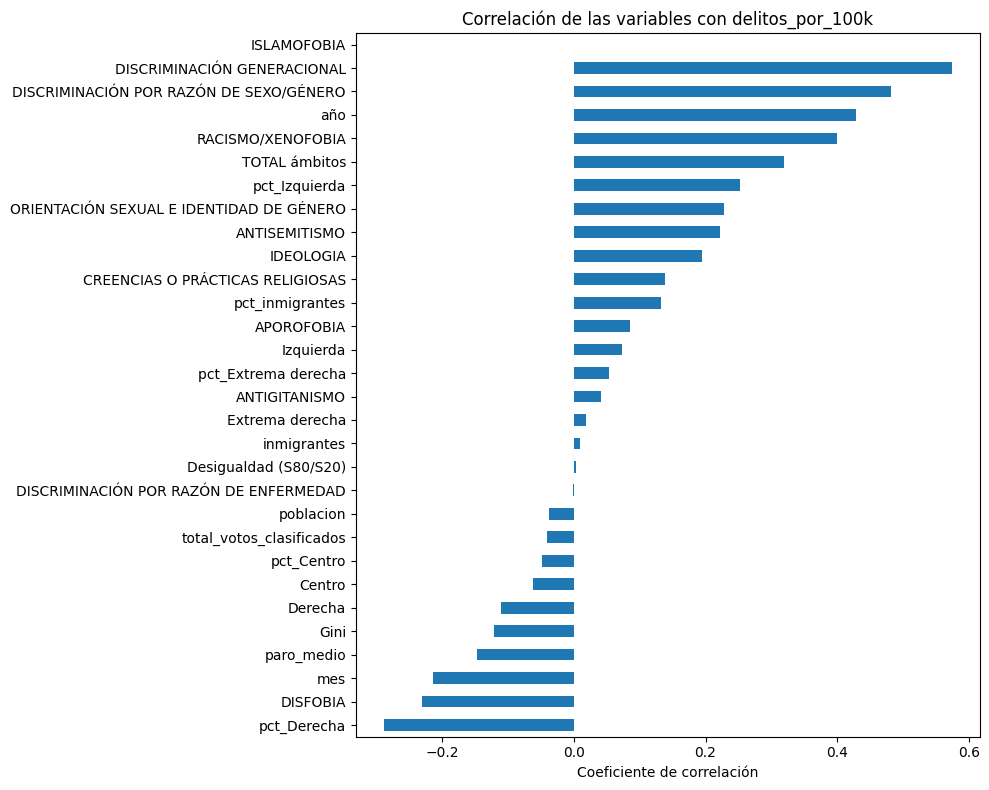

In [21]:
correlaciones = (
    datos_anual
    .corr(numeric_only=True)["delitos_por_100k"]
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 8))

correlaciones.drop("delitos_por_100k").sort_values().plot(
    kind="barh"
)

plt.title("Correlación de las variables con delitos_por_100k")
plt.xlabel("Coeficiente de correlación")
plt.tight_layout()
plt.show()

### Interpretación

Las correlaciones observadas muestran asociaciones generalmente débiles o moderadas con la tasa de delitos de odio.

Entre las variables analizadas, el año presenta una de las correlaciones positivas más elevadas, lo que refuerza la existencia de una tendencia creciente durante el periodo estudiado.

Las variables de inmigración, desempleo y desigualdad muestran asociaciones reducidas, mientras que las variables electorales presentan relaciones moderadas que deben interpretarse con cautela debido a la elevada dispersión observada en los datos.

<Axes: xlabel='pct_Derecha', ylabel='delitos_por_100k'>

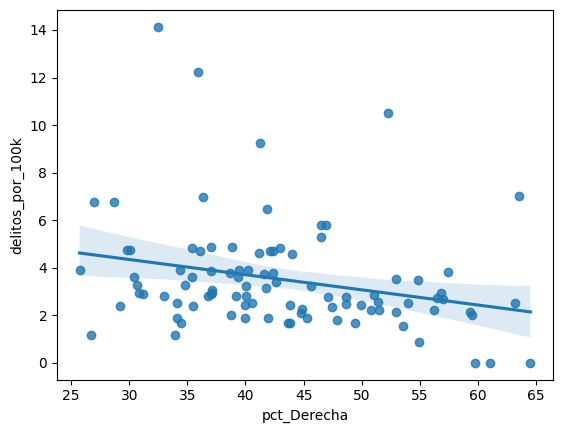

In [22]:
sns.regplot(
    data=datos_elecciones,
    x="pct_Derecha",
    y="delitos_por_100k"
)

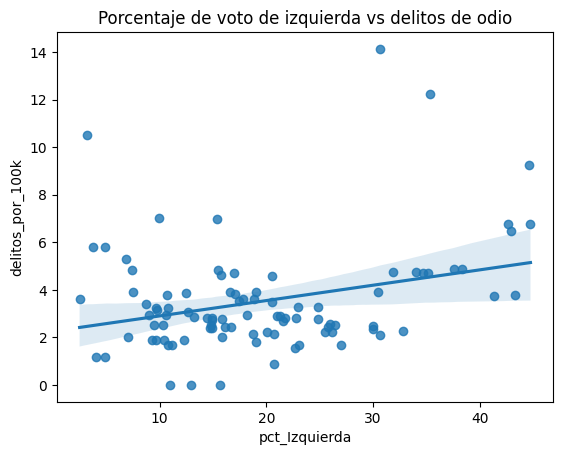

In [23]:
sns.regplot(
    data=datos_elecciones,
    x="pct_Izquierda",
    y="delitos_por_100k"
)

plt.title("Porcentaje de voto de izquierda vs delitos de odio")
plt.show()

## 12. Clustering de comunidades autónomas

Aplicamos K-means para agrupar las observaciones (comunidad+año) según
un perfil combinado de variables políticas, socioeconómicas y la propia
tasa de delitos de odio. Las variables se estandarizan previamente
(StandardScaler) para que ninguna domine por su escala.

El método del codo sugiere `k=3` como número razonable de clusters.

**Nota**: como `delitos_por_100k` se incluye entre las variables de
clustering, los grupos resultantes reflejan en parte esa misma variable.
El objetivo no es "predecir" delitos de odio de forma independiente,
sino identificar **perfiles territoriales** que combinan varios factores
a la vez.

In [24]:
variables_cluster = datos_anual[
    [
        'pct_Derecha',
        'pct_Izquierda',
        'pct_Extrema derecha',
        'pct_inmigrantes',
        'paro_medio',
        'Gini',
        'delitos_por_100k'
    ]
]

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

variables_cluster_scaled = scaler.fit_transform(
    variables_cluster
)

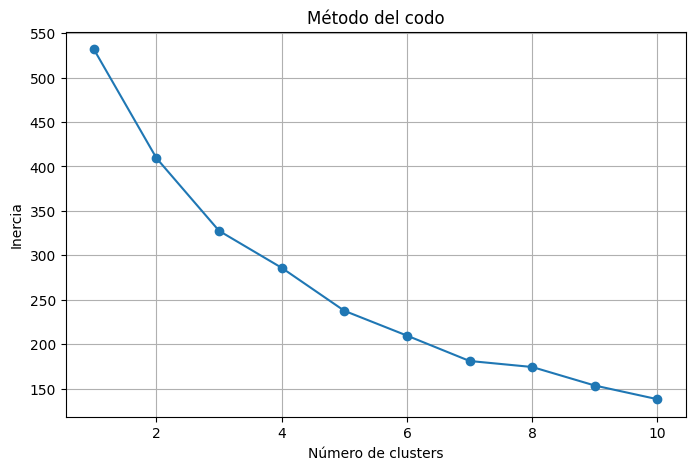

In [26]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inercias = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(variables_cluster_scaled)

    inercias.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), inercias, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.title('Método del codo')
plt.grid(True)
plt.show()

In [27]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

datos_anual["cluster"] = kmeans.fit_predict(
    variables_cluster_scaled
)

In [28]:
datos_anual.groupby("cluster")[
    [
        "pct_Derecha",
        "pct_Izquierda",
        "pct_Extrema derecha",
        "pct_inmigrantes",
        "paro_medio",
        "Gini",
        "delitos_por_100k",
    ]
].mean().round(2)

,pct_Derecha,pct_Izquierda,pct_Extrema derecha,pct_inmigrantes,paro_medio,Gini,delitos_por_100k
cluster,,,,,,,
0,36.07,38.22,2.59,10.14,200353.25,29.32,6.62
1,53.30,20.91,0.37,9.00,207220.88,32.58,2.39
2,37.52,12.00,17.20,10.46,153976.65,31.57,3.67


## 13. Principales hallazgos del análisis exploratorio

El análisis exploratorio de los datos permite identificar varios patrones relevantes en la evolución de los delitos de odio en España entre 2015 y 2023.

### Evolución temporal

La tasa de delitos de odio por 100.000 habitantes muestra una tendencia creciente durante el periodo analizado. Esta evolución no parece concentrarse en territorios concretos, sino que presenta un carácter ampliamente generalizado.

### Diferencias territoriales

Existen diferencias significativas entre comunidades autónomas. País Vasco y Navarra presentan las tasas medias más elevadas del periodo, seguidas por Melilla, Cataluña y Asturias.

### Comparación entre 2019 y 2023

Entre 2019 y 2023 se observa un incremento de la tasa de delitos de odio en 18 de las 19 comunidades y ciudades autónomas analizadas. Cataluña constituye la única excepción, registrando una reducción respecto a 2019.

Los mayores incrementos corresponden a Navarra, País Vasco y Melilla.

### Factores socioeconómicos y demográficos

Las correlaciones observadas entre la tasa de delitos de odio y variables como inmigración, desempleo o desigualdad son débiles. Esto sugiere que estas variables, por sí solas, no explican adecuadamente las diferencias observadas entre territorios.

### Factores políticos

Las variables relacionadas con el comportamiento electoral muestran asociaciones moderadas, aunque la dispersión observada en los datos aconseja interpretar estos resultados con cautela. No se observa evidencia suficiente para establecer relaciones causales entre orientación política y delitos de odio.

### Importancia del factor temporal

La variable año presenta una de las correlaciones más elevadas con la tasa de delitos de odio. Junto con el aumento observado en la mayoría de comunidades autónomas, este resultado sugiere la existencia de dinámicas temporales comunes que afectan al conjunto del territorio nacional.


## Próximos pasos

Los resultados obtenidos permiten identificar patrones generales, pero no explican completamente las causas de la evolución observada.

Como continuación del proyecto, se plantea ampliar el análisis mediante técnicas de procesamiento del lenguaje natural (NLP) aplicadas a noticias, discursos políticos y contenido en redes sociales, con el objetivo de estudiar la posible influencia del discurso público en la evolución de los delitos de odio.

In [29]:
scatter = datos_elecciones[
    [
        "comunidad",
        "año",
        "mes",
        "delitos_por_100k",
        "pct_Extrema derecha",
        "pct_Derecha",
        "pct_Centro",
        "pct_Izquierda",
    ]
]

scatter.to_csv(
    r"C:\Users\herre\OneDrive\Desktop\Proyectos DATA\SPRINT 13\03_outputs\tables\elecciones_delitos_odio\scatter_extrema_derecha.csv",
    index=False
)

In [30]:
mapa = datos_anual[
    datos_anual["año"] == 2023
][
    [
        "comunidad",
        "delitos_por_100k",
    ]
]

mapa.head()

,comunidad,delitos_por_100k
76,Andalucía,3.844296
77,Aragón,3.056761
78,Asturias,6.957836
79,Baleares,4.711110
80,Canarias,3.795725


In [31]:
datos_anual[['delitos_por_100k',
       'pct_Extrema derecha',
       'pct_Derecha',
       'pct_Centro',
       'pct_Izquierda',
       'paro_medio',
       'pct_inmigrantes',
       'Gini']].corr()



,delitos_por_100k,pct_Extrema derecha,pct_Derecha,pct_Centro,pct_Izquierda,paro_medio,pct_inmigrantes,Gini
delitos_por_100k,1.000000,0.053825,-0.288237,-0.048792,0.253106,-0.146431,0.132925,-0.120756
pct_Extrema derecha,0.053825,1.000000,-0.635047,0.537377,-0.581310,-0.119994,0.145954,0.113947
pct_Derecha,-0.288237,-0.635047,1.000000,-0.447315,-0.123646,-0.102086,-0.070752,0.261708
pct_Centro,-0.048792,0.537377,-0.447315,1.000000,-0.645054,-0.057045,-0.158097,-0.123861
pct_Izquierda,0.253106,-0.581310,-0.123646,-0.645054,1.000000,0.231714,0.038241,-0.265826
paro_medio,-0.146431,-0.119994,-0.102086,-0.057045,0.231714,1.000000,0.046660,0.210898
pct_inmigrantes,0.132925,0.145954,-0.070752,-0.158097,0.038241,0.046660,1.000000,0.075245
Gini,-0.120756,0.113947,0.261708,-0.123861,-0.265826,0.210898,0.075245,1.000000


In [32]:
datos_anual[['delitos_por_100k',
       'RACISMO/XENOFOBIA',
       'ORIENTACIÓN SEXUAL E IDENTIDAD DE GÉNERO',
       'IDEOLOGIA',
       'pct_Extrema derecha',
       'pct_Derecha',
       'pct_Izquierda']].corr().round(2)

,delitos_por_100k,RACISMO/XENOFOBIA,ORIENTACIÓN SEXUAL E IDENTIDAD DE GÉNERO,IDEOLOGIA,pct_Extrema derecha,pct_Derecha,pct_Izquierda
delitos_por_100k,1.00,0.40,0.23,0.20,0.05,-0.29,0.25
RACISMO/XENOFOBIA,0.40,1.00,0.82,0.57,0.01,-0.35,0.42
ORIENTACIÓN SEXUAL E IDENTIDAD DE GÉNERO,0.23,0.82,1.00,0.71,0.05,-0.39,0.33
IDEOLOGIA,0.20,0.57,0.71,1.00,-0.00,-0.36,0.43
pct_Extrema derecha,0.05,0.01,0.05,-0.00,1.00,-0.64,-0.58
pct_Derecha,-0.29,-0.35,-0.39,-0.36,-0.64,1.00,-0.12
pct_Izquierda,0.25,0.42,0.33,0.43,-0.58,-0.12,1.00


In [33]:
datos_2023 = datos_anual[
    datos_anual["año"] == 2023
]

datos_2023[
    [
        "delitos_por_100k",
        "pct_Extrema derecha",
        "pct_Derecha",
        "pct_Izquierda",
        "pct_inmigrantes",
        "Gini",
        "paro_medio",
    ]
].corr().round(2)

,delitos_por_100k,pct_Extrema derecha,pct_Derecha,pct_Izquierda,pct_inmigrantes,Gini,paro_medio
delitos_por_100k,1.00,-0.48,-0.03,0.53,0.02,0.24,-0.23
pct_Extrema derecha,-0.48,1.00,0.24,-0.74,0.05,0.40,-0.03
pct_Derecha,-0.03,0.24,1.00,-0.68,-0.20,0.30,-0.34
pct_Izquierda,0.53,-0.74,-0.68,1.00,0.20,-0.34,0.18
pct_inmigrantes,0.02,0.05,-0.20,0.20,1.00,-0.07,0.15
Gini,0.24,0.40,0.30,-0.34,-0.07,1.00,-0.00
paro_medio,-0.23,-0.03,-0.34,0.18,0.15,-0.00,1.00


In [34]:
datos_2023.sort_values(
    'delitos_por_100k',
    ascending=False
)[[
    'comunidad',
    'delitos_por_100k',
    'pct_Extrema derecha',
    'pct_Izquierda'
]].head(10)

,comunidad,delitos_por_100k,pct_Extrema derecha,pct_Izquierda
93,Navarra,14.133645,5.783319,30.617380
94,País Vasco,12.227575,2.670815,35.391118
91,Melilla,10.527178,16.938022,3.213522
78,Asturias,6.957836,12.729098,15.401711
89,La Rioja,5.274883,9.944610,6.818261
82,Castilla y León,4.824427,14.236544,7.398494
86,Comunidad Valenciana,4.811937,15.863837,15.446249
79,Baleares,4.711110,15.407670,16.949303
90,Madrid,4.627539,14.230582,15.777529
88,Galicia,4.556528,4.919498,20.542323


In [35]:
datos_2023_sin = datos_2023[
    ~datos_2023['comunidad'].isin(['Navarra', 'País Vasco'])
]

datos_2023_sin[['delitos_por_100k',
                'pct_Extrema derecha',
                'pct_Izquierda']].corr().round(2)

,delitos_por_100k,pct_Extrema derecha,pct_Izquierda
delitos_por_100k,1.00,-0.03,-0.14
pct_Extrema derecha,-0.03,1.00,-0.58
pct_Izquierda,-0.14,-0.58,1.00


In [36]:
scatter_2023 = datos_anual[
    datos_anual["año"] == 2023
][
    [
        "comunidad",
        "delitos_por_100k",
        "pct_Extrema derecha",
    ]
]

scatter_2023.to_csv(
    r"C:\Users\herre\OneDrive\Desktop\Proyectos DATA\SPRINT 13\03_outputs\tables\elecciones_delitos_odio\scatter_2023.csv",
    index=False
)

In [37]:
datos.columns

Index(['año', 'mes', 'comunidad', 'Centro', 'Derecha', 'Extrema derecha',
       'Izquierda', 'total_votos_clasificados', 'pct_Centro', 'pct_Derecha',
       'pct_Extrema derecha', 'pct_Izquierda', 'paro_medio', 'inmigrantes',
       'poblacion', 'Desigualdad (S80/S20)', 'Gini', 'ANTIGITANISMO',
       'ANTISEMITISMO', 'APOROFOBIA', 'CREENCIAS O PRÁCTICAS RELIGIOSAS',
       'DISCRIMINACIÓN GENERACIONAL', 'DISCRIMINACIÓN POR RAZÓN DE ENFERMEDAD',
       'DISCRIMINACIÓN POR RAZÓN DE SEXO/GÉNERO', 'DISFOBIA', 'IDEOLOGIA',
       'ISLAMOFOBIA', 'ORIENTACIÓN SEXUAL E IDENTIDAD DE GÉNERO',
       'RACISMO/XENOFOBIA', 'TOTAL ámbitos', 'pct_inmigrantes',
       'delitos_por_100k'],
      dtype='object')

In [38]:
social_anual = (
    datos_anual
    .groupby("año")[
        [
            "paro_medio",
            "pct_inmigrantes",
            "Gini",
            "Desigualdad (S80/S20)",
        ]
    ]
    .mean()
    .reset_index()
)

social_anual

,año,paro_medio,pct_inmigrantes,Gini,Desigualdad (S80/S20)
0,2015,222721.421053,9.090452,32.294737,6.363158
1,2016,203626.210526,9.038631,32.152632,5.942105
2,2019,165723.947368,9.645426,31.394737,6.100000
3,2023,145602.315789,11.329677,30.768421,5.594737


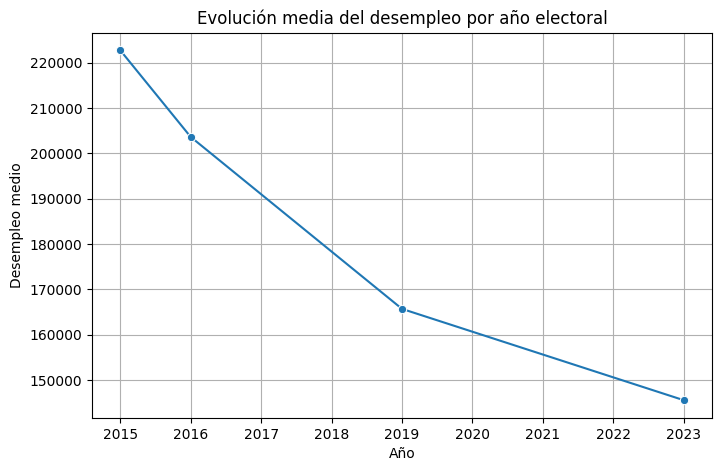

In [39]:
plt.figure(figsize=(8,5))

sns.lineplot(
    data=social_anual,
    x='año',
    y='paro_medio',
    marker='o'
)

plt.title('Evolución media del desempleo por año electoral')
plt.xlabel('Año')
plt.ylabel('Desempleo medio')
plt.grid(True)
plt.show()

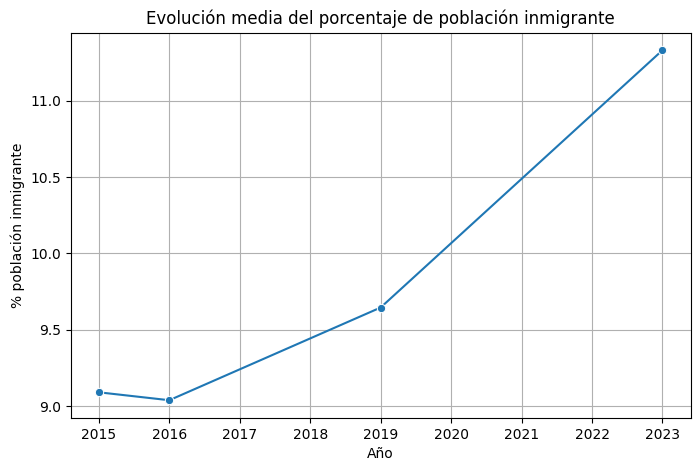

In [40]:
plt.figure(figsize=(8,5))

sns.lineplot(
    data=social_anual,
    x='año',
    y='pct_inmigrantes',
    marker='o'
)

plt.title('Evolución media del porcentaje de población inmigrante')
plt.xlabel('Año')
plt.ylabel('% población inmigrante')
plt.grid(True)
plt.show()

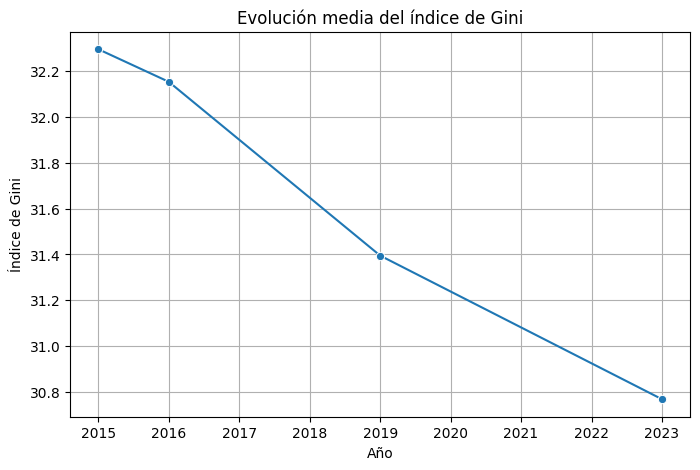

In [41]:
plt.figure(figsize=(8,5))

sns.lineplot(
    data=social_anual,
    x='año',
    y='Gini',
    marker='o'
)

plt.title('Evolución media del índice de Gini')
plt.xlabel('Año')
plt.ylabel('Índice de Gini')
plt.grid(True)
plt.show()

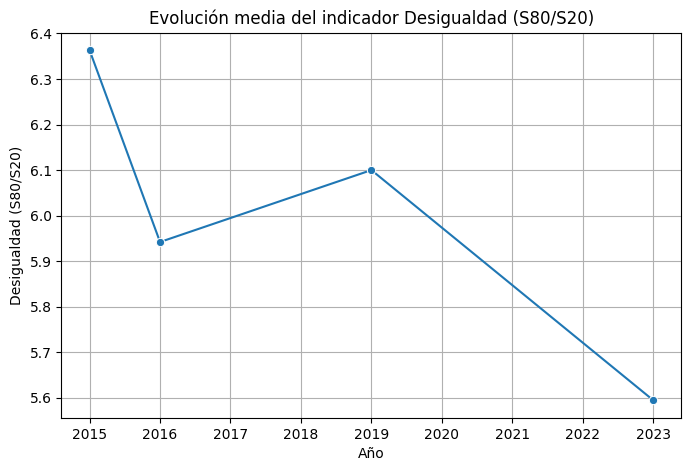

In [42]:
plt.figure(figsize=(8,5))

sns.lineplot(
    data=social_anual,
    x='año',
    y='Desigualdad (S80/S20)',
    marker='o'
)

plt.title('Evolución media del indicador Desigualdad (S80/S20)')
plt.xlabel('Año')
plt.ylabel('Desigualdad (S80/S20)')
plt.grid(True)
plt.show()

In [43]:
social_anual.round(2)

,año,paro_medio,pct_inmigrantes,Gini,Desigualdad (S80/S20)
0,2015,222721.42,9.09,32.29,6.36
1,2016,203626.21,9.04,32.15,5.94
2,2019,165723.95,9.65,31.39,6.10
3,2023,145602.32,11.33,30.77,5.59


Análisis por CCAA de los valores socioeconómicos

In [44]:
# Ranking medio por CCAA de variables socioeconómicas
ranking_social = (
    datos_anual
    .groupby("comunidad")[
        [
            "paro_medio",
            "pct_inmigrantes",
            "Gini",
            "Desigualdad (S80/S20)",
        ]
    ]
    .mean()
    .round(2)
    .reset_index()
)

ranking_social

,comunidad,paro_medio,pct_inmigrantes,Gini,Desigualdad (S80/S20)
0,Andalucía,858514.25,7.98,34.28,6.55
1,Aragón,74253.75,11.65,29.18,4.88
2,Asturias,76717.50,4.16,31.15,5.88
3,Baleares,51397.00,18.54,31.50,6.28
4,Canarias,217659.00,12.71,33.85,7.38
5,Cantabria,39830.25,5.75,29.08,4.72
6,Castilla y León,160467.50,5.82,29.68,5.07
7,Castilla-La Mancha,183163.00,8.99,32.02,5.90
8,Cataluña,431532.25,14.14,31.20,5.57
9,Ceuta,11937.25,6.09,38.22,8.62


In [45]:
ranking_social.sort_values('paro_medio', ascending=False).head(5)

,comunidad,paro_medio,pct_inmigrantes,Gini,Desigualdad (S80/S20)
0,Andalucía,858514.25,7.98,34.28,6.55
8,Cataluña,431532.25,14.14,31.20,5.57
10,Comunidad Valenciana,406922.00,14.26,32.00,5.90
14,Madrid,389383.25,12.50,34.00,6.48
4,Canarias,217659.00,12.71,33.85,7.38


In [46]:
ranking_social.sort_values('pct_inmigrantes', ascending=False).head(5)

,comunidad,paro_medio,pct_inmigrantes,Gini,Desigualdad (S80/S20)
3,Baleares,51397.00,18.54,31.50,6.28
10,Comunidad Valenciana,406922.00,14.26,32.00,5.90
16,Murcia,110406.00,14.25,30.62,5.42
8,Cataluña,431532.25,14.14,31.20,5.57
15,Melilla,10413.50,13.90,37.58,10.25


In [47]:
ranking_social.sort_values('Gini', ascending=False).head(5)

,comunidad,paro_medio,pct_inmigrantes,Gini,Desigualdad (S80/S20)
9,Ceuta,11937.25,6.09,38.22,8.62
15,Melilla,10413.50,13.90,37.58,10.25
0,Andalucía,858514.25,7.98,34.28,6.55
14,Madrid,389383.25,12.50,34.00,6.48
4,Canarias,217659.00,12.71,33.85,7.38


In [48]:
ranking_social.sort_values('Desigualdad (S80/S20)', ascending=False).head(5)

,comunidad,paro_medio,pct_inmigrantes,Gini,Desigualdad (S80/S20)
15,Melilla,10413.50,13.90,37.58,10.25
9,Ceuta,11937.25,6.09,38.22,8.62
4,Canarias,217659.00,12.71,33.85,7.38
0,Andalucía,858514.25,7.98,34.28,6.55
14,Madrid,389383.25,12.50,34.00,6.48


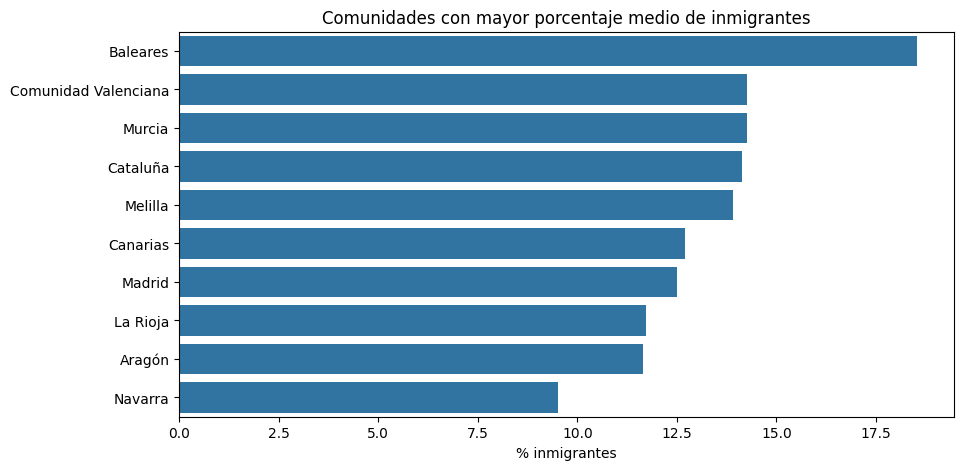

In [49]:
top_inmigracion = ranking_social.sort_values(
    'pct_inmigrantes',
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    data=top_inmigracion,
    x='pct_inmigrantes',
    y='comunidad'
)

plt.title('Comunidades con mayor porcentaje medio de inmigrantes')
plt.xlabel('% inmigrantes')
plt.ylabel('')
plt.show()

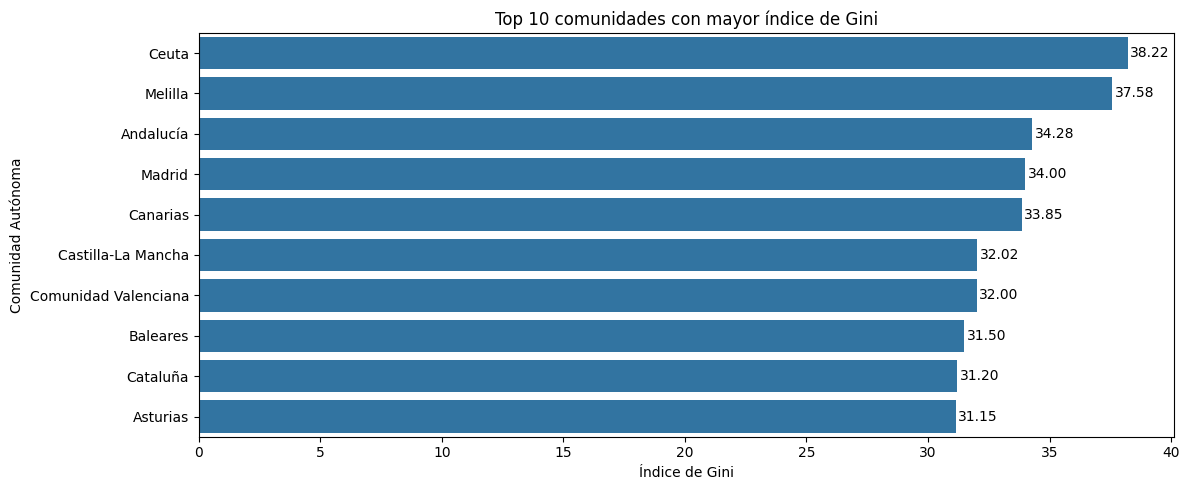

In [50]:
plt.figure(figsize=(12,5))
top_gini = ranking_social.sort_values(
    'Gini',
    ascending=False
).head(10)

ax = sns.barplot(
    data=top_gini,
    x='Gini',
    y='comunidad'
)

plt.title('Top 10 comunidades con mayor índice de Gini')
plt.xlabel('Índice de Gini')
plt.ylabel('Comunidad Autónoma')

for i, valor in enumerate(top_gini['Gini']):
    ax.text(valor + 0.1, i, f'{valor:.2f}', va='center')

plt.tight_layout()
plt.show()

In [51]:
corr = datos_anual[
    [
        "delitos_por_100k",
        "paro_medio",
        "pct_inmigrantes",
        "Gini",
        "Desigualdad (S80/S20)",
    ]
].corr()

corr.round(2)

,delitos_por_100k,paro_medio,pct_inmigrantes,Gini,Desigualdad (S80/S20)
delitos_por_100k,1.00,-0.15,0.13,-0.12,0.00
paro_medio,-0.15,1.00,0.05,0.21,0.04
pct_inmigrantes,0.13,0.05,1.00,0.08,0.16
Gini,-0.12,0.21,0.08,1.00,0.91
Desigualdad (S80/S20),0.00,0.04,0.16,0.91,1.00
